<a href="https://colab.research.google.com/github/saatour/GW170817/blob/main/WEAVE%20ETC%2002032026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Installation (execute only if running on a cloud platform!)¶

In [1]:
# -- Use the following line for google colab removing the hash at the beginning.
! pip install -q 'corner==2.2.2' 'bilby==2.2.2' 'astropy==6.0.1'

In [2]:
import os, glob
glob.glob("signalWEAVE*.tar.gz"), os.getcwd()

(['signalWEAVE.5.1.tar.gz'], '/content')

In [3]:
!tar -xvf signalWEAVE.5.1.tar.gz

._signalWEAVE
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
signalWEAVE
._signal2noise.py
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
signal2noise.py


In [4]:
!find . -maxdepth 3 -type f -name "signalWEAVE" -print

./signalWEAVE


In [5]:
!chmod +x ./signalWEAVE.5.1/signalWEAVE

chmod: cannot access './signalWEAVE.5.1/signalWEAVE': No such file or directory


In [7]:
!chmod +x ./signalWEAVE

In [8]:
!./signalWEAVE -h

usage: signalWEAVE [-h]
                   [--instrument_mode {blueLR,redLR,blueHR,greenHR,redHR}]
                   [--LIFU] [--sb] [--band {U,B,V,R,I}] [--X AIRMASS]
                   [--FWHM SEEING] [--profile {Moffat,Gaussian}]
                   [--betam BETAM] [--sky SKYSB] [--skyband {U,B,V,R,I}]
                   [--readnoise RN] [--dark DARK] [--offset OFFSET] [--rv]
                   mag time

Exposure time calculator for WEAVE.

positional arguments:
  mag                   Magnitude of object (defaults to point source
                        magnitude; if -sb switch is used, should be given as
                        mag/sq. arcsec
  time                  Exposure time in seconds

options:
  -h, --help            show this help message and exit
  --instrument_mode {blueLR,redLR,blueHR,greenHR,redHR}
                        VPH grating [default: blueLR]
  --LIFU                Fibre mode [default: MOS]
  --sb                  Surface brightness mode [default: False]
  --

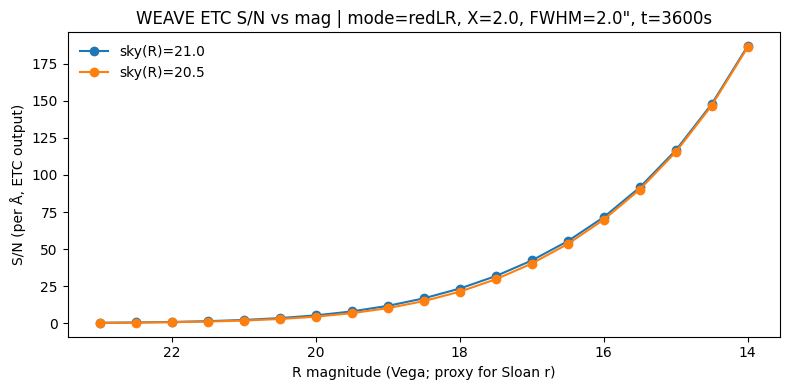

mag   S/N(sky=21.0)   S/N(sky=20.5)
14.0      186.80          186.04
14.5      147.72          146.78
15.0      116.52          115.37
15.5       91.55           90.16
16.0       71.51           69.86
16.5       55.37           53.48
17.0       42.35           40.27
17.5       31.84           29.69
18.0       23.44           21.36
18.5       16.83           14.97
19.0       11.77           10.23
19.5        8.03            6.84
20.0        5.36            4.49
20.5        3.52            2.91
21.0        2.28            1.87
21.5        1.46            1.19
22.0        0.93            0.76
22.5        0.59            0.48
23.0        0.38            0.30


In [11]:
import subprocess, re
import numpy as np
import matplotlib.pyplot as plt

SIGNAL = "./signalWEAVE"   # because it extracted into the current directory

# --- Settings requested ---
airmass = 2.0
seeing_fwhm = 2.0          # arcsec
exptime = 3600             # seconds
band = "R"                 # closest proxy to Sloan r
mode = "redLR"             # low-res red arm (good for redshift work)

# Sky brightness assumption in R, mag/arcsec^2 (between sky lines)
# Dark-ish R ~ 21.0; try 20.5 as a "brighter sky" stress test
sky_R = 21.0
skyband = "R"

mags = np.arange(14, 23.5, 0.5)

def run_signalweave(mag, sky_val=21.0):
    cmd = [
        SIGNAL,
        "--instrument_mode", mode,
        "--band", band,
        "--X", str(airmass),
        "--FWHM", str(seeing_fwhm),
        "--sky", str(sky_val),
        "--skyband", skyband,
        str(mag),
        str(exptime),
    ]
    out = subprocess.check_output(cmd, text=True, stderr=subprocess.STDOUT)

    # Robust parse: look for "S/N" followed by a number
    m = re.search(r"S/N[^0-9]*([0-9]+(?:\.[0-9]+)?)", out)
    if m:
        return float(m.group(1)), out

    # Fallback: last float on last non-empty line
    lines = [ln.strip() for ln in out.splitlines() if ln.strip()]
    floats = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", lines[-1]) if lines else []
    if floats:
        return float(floats[-1]), out

    raise RuntimeError(f"Could not parse S/N for mag={mag}.\nOutput head:\n{out[:400]}")

# --- Generate curve(s) ---
sn_dark = []
for mag in mags:
    sn, _ = run_signalweave(mag, sky_val=sky_R)
    sn_dark.append(sn)
sn_dark = np.array(sn_dark)

# Optional "brighter sky" scenario
sn_bright = []
for mag in mags:
    sn, _ = run_signalweave(mag, sky_val=20.5)
    sn_bright.append(sn)
sn_bright = np.array(sn_bright)

# --- Plot ---
plt.figure(figsize=(8,4))
plt.plot(mags, sn_dark, marker="o", label=f"sky(R)={sky_R}")
plt.plot(mags, sn_bright, marker="o", label="sky(R)=20.5")
plt.gca().invert_xaxis()
plt.xlabel("R magnitude (Vega; proxy for Sloan r)")
plt.ylabel("S/N (per Å, ETC output)")
plt.title(f"WEAVE ETC S/N vs mag | mode={mode}, X={airmass}, FWHM={seeing_fwhm}\", t={exptime}s")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Print a quick reference table for proposal text
print("mag   S/N(sky=21.0)   S/N(sky=20.5)")
for m, s1, s2 in zip(mags, sn_dark, sn_bright):
    print(f"{m:4.1f}     {s1:7.2f}         {s2:7.2f}")